# Zadanie 2. Klasyfikacja typów otyłości - DBSCAN

Plik `ObesityDataSet.csv` zawiera dane dotyczące nawyków żywieniowych i kondycji fizycznej osób z Meksyku, Peru i Kolumbii. Choć w danych znajduje się kolumna `NObeyesdad` (poziom otyłości), w klasteryzacji **nie używamy etykiet**. Etykietę można wykorzystać jedynie do oceny jakości znalezionych klastrów.

## Import bibliotek

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings('ignore')
sns.set_theme()

## Wczytanie danych

In [25]:
df = pd.read_csv('ObesityDataSet.csv')
print('Wymiar:', df.shape)
df.head()

Wymiar: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [27]:
print('Liczba zdublowanych wierszy:', df.duplicated().sum())

Liczba zdublowanych wierszy: 24


### Rozkłady zmiennych numerycznych

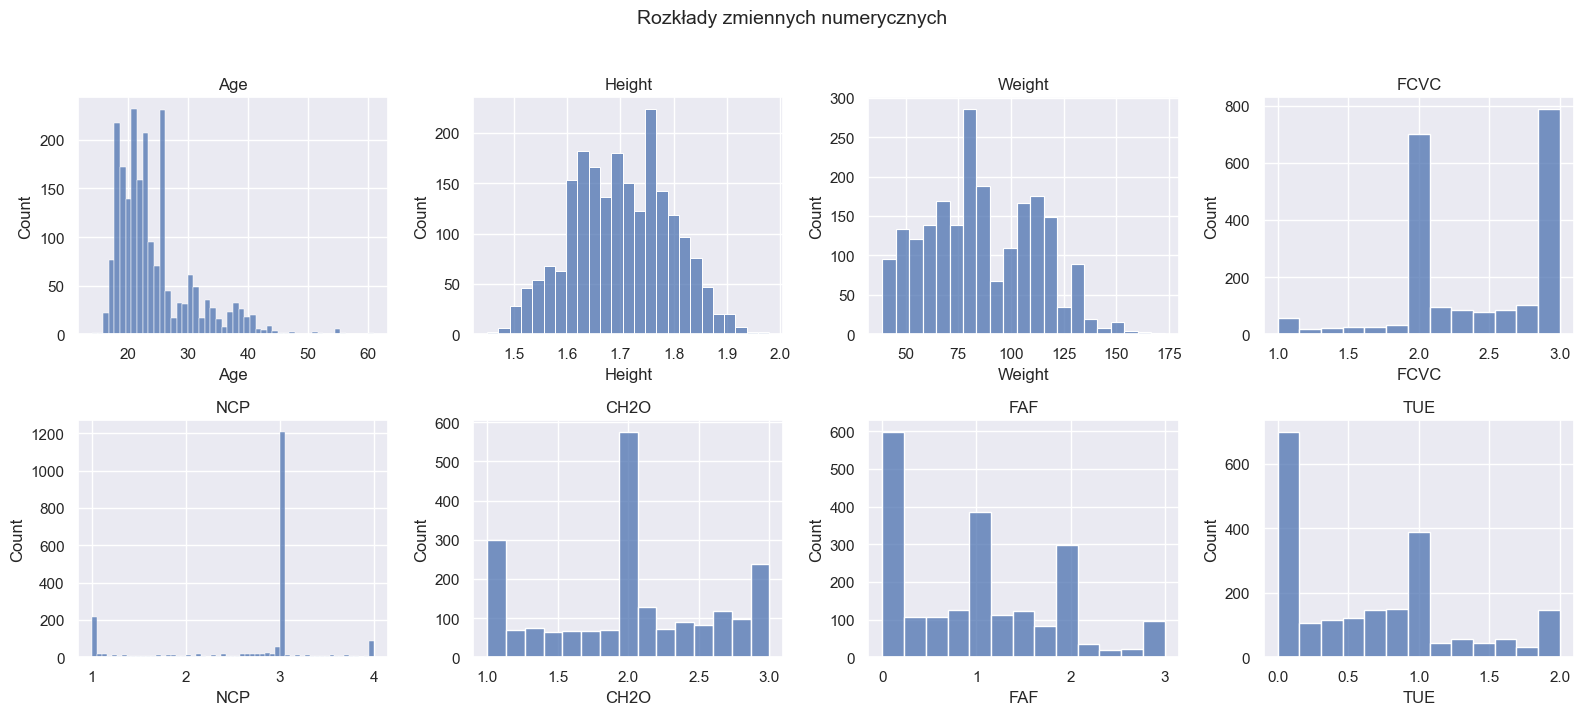

In [28]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], ax=ax)
    ax.set_title(col)
fig.suptitle('Rozkłady zmiennych numerycznych', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### Rozkłady zmiennych kategorycznych

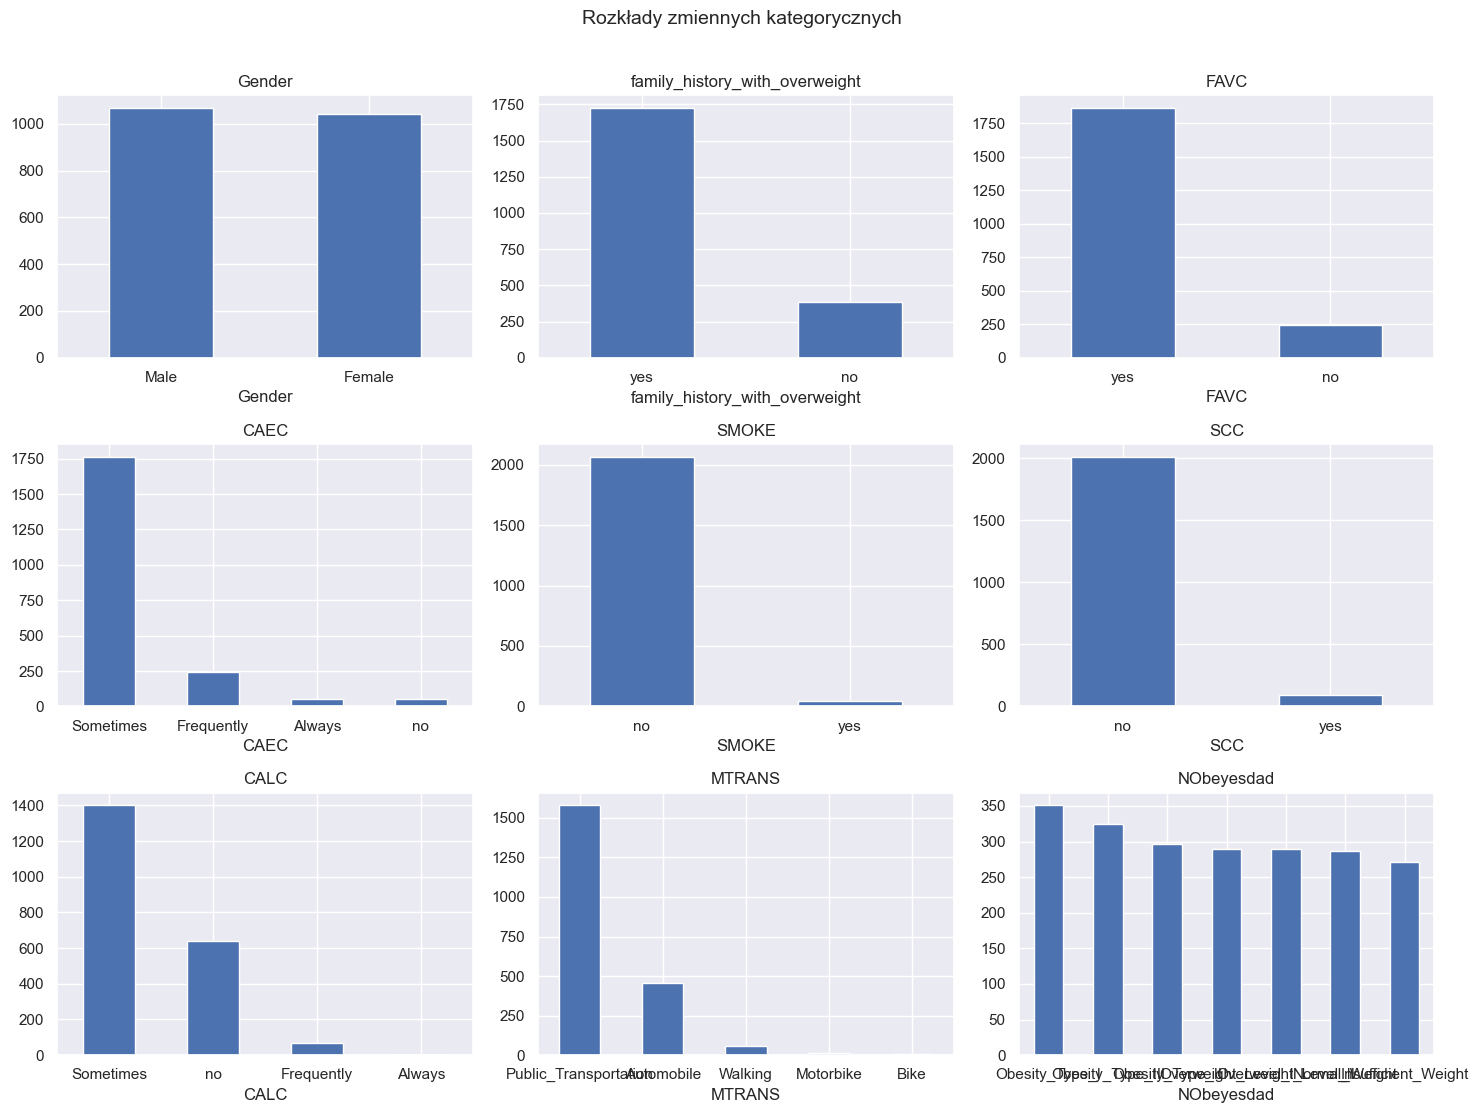

In [29]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation= 0)
for ax in axes.flatten()[len(cat_cols):]:
    ax.axis('off')
fig.suptitle('Rozkłady zmiennych kategorycznych', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Macierz korelacji zmiennych numerycznych

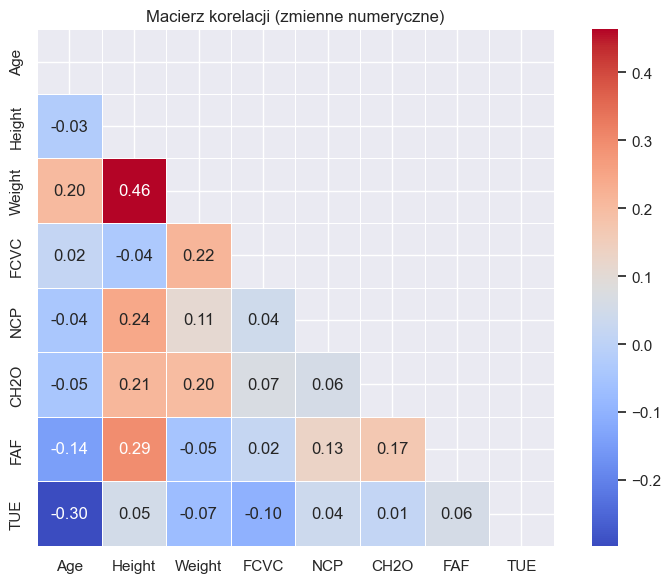

In [30]:
plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Macierz korelacji (zmienne numeryczne)')
plt.tight_layout()
plt.show()

### Wykresy parami (BMI – Wzrost vs Waga z podziałem na klasy)

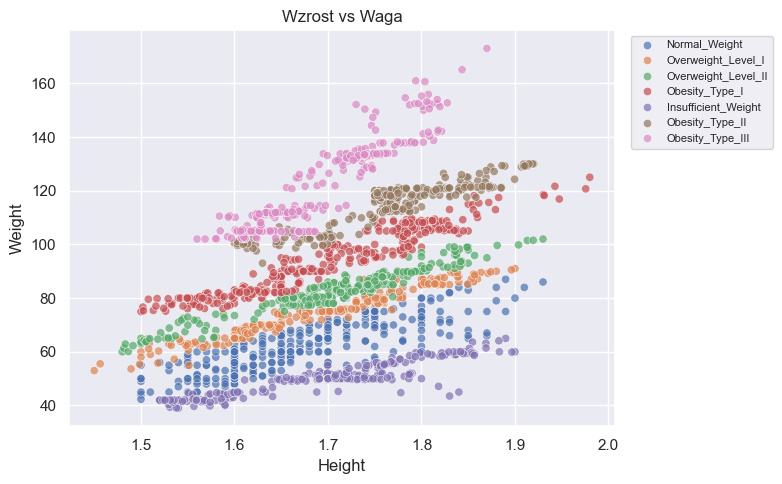

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad', alpha=0.7)
plt.title('Wzrost vs Waga')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
df_clean = df.copy()
print('Duplikaty przed czyszczeniem:', df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print('Duplikaty po czyszczeniu: ', df_clean.duplicated().sum())
print('Wymiar po czyszczeniu:    ', df_clean.shape)

Duplikaty przed czyszczeniem: 24
Duplikaty po czyszczeniu:  0
Wymiar po czyszczeniu:     (2087, 17)


In [33]:
for col in cat_cols:
    uniq = df_clean[col].unique()
    print(f'{col}: {len(uniq)} unikalnych - {list(uniq)}')

Gender: 2 unikalnych - ['Female', 'Male']
family_history_with_overweight: 2 unikalnych - ['yes', 'no']
FAVC: 2 unikalnych - ['no', 'yes']
CAEC: 4 unikalnych - ['Sometimes', 'Frequently', 'Always', 'no']
SMOKE: 2 unikalnych - ['no', 'yes']
SCC: 2 unikalnych - ['no', 'yes']
CALC: 4 unikalnych - ['no', 'Sometimes', 'Frequently', 'Always']
MTRANS: 5 unikalnych - ['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
NObeyesdad: 7 unikalnych - ['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II', 'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II', 'Obesity_Type_III']


In [34]:
df_enc = df_clean.copy()


y_true = df_enc['NObeyesdad']
df_enc = df_enc.drop(columns=['NObeyesdad'])


binary_yesno = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_yesno:
    df_enc[col] = df_enc[col].map({'yes': 1, 'no': 0})
df_enc['Gender'] = df_enc['Gender'].map({'Male': 1, 'Female': 0})


caec_calc_map = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
df_enc['CAEC'] = df_enc['CAEC'].map(caec_calc_map)
df_enc['CALC'] = df_enc['CALC'].map(caec_calc_map)


df_enc['MTRANS'] = LabelEncoder().fit_transform(df_enc['MTRANS'].astype(str))

print('Typy po kodowaniu:')
print(df_enc.dtypes)
df_enc.head()

Typy po kodowaniu:
Gender                              int64
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                int64
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                int64
MTRANS                              int64
dtype: object


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,3
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,3
2,1,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,3
3,1,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,4
4,1,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,3


### Wybór zmiennych do grupowania

Pomijamy `Height` i `Weight` (cechy fizyczne, nie behawioralne) oraz `NObeyesdad` (etykieta, używana tylko do oceny, nie do grupowania).

In [35]:
features = [
    'Gender', 'Age', 'family_history_with_overweight', 'FAVC',
    'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS'
]

df_features = df_enc[features].copy()
print(f'Wybrane zmienne ({len(features)}):', features)
print('Wymiar zbioru cech:', df_features.shape)
df_features.head()

Wybrane zmienne (14): ['Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS']
Wymiar zbioru cech: (2087, 14)


,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
0,0,21.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,3
1,0,21.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,3
2,1,23.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,3
3,1,27.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,4
4,1,22.0,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,3


## Standaryzacja

In [36]:
scaler = StandardScaler()
X = scaler.fit_transform(df_features)
X.shape

(2087, 14)

### DBSCAN

In [37]:
import plotly.graph_objects as go

min_pts = 17
nn = NearestNeighbors(n_neighbors=min_pts).fit(X)
dist, _ = nn.kneighbors(X)
k_dist = np.sort(dist[:, -1])

n = len(k_dist)

fig = go.FigureWidget()

# Krzywa k-distance
fig.add_scatter(x=list(range(n)), y=k_dist,
                mode="lines", name="k-distance",
                line=dict(color="steelblue", width=2))

# Linie i punkt
fig.add_scatter(x=[], y=[], mode="lines", name="eps (pozioma)",
                line=dict(color="darkorange", width=2, dash="dashdot"))
fig.add_scatter(x=[], y=[], mode="lines", name="lokieć (pionowa)",
                line=dict(color="crimson", width=2, dash="dot"))
fig.add_scatter(x=[], y=[], mode="markers+text", name="lokieć",
                marker=dict(color="crimson", size=10),
                text=[], textposition="top right",
                textfont=dict(color="crimson", size=12))

fig.update_layout(
    title="k-distance plot",
    xaxis_title="punkty (posortowane)",
    yaxis_title=f"odległość do {min_pts}-tego sąsiada",
    legend=dict(x=0.02, y=0.95),
    hovermode="x unified"
)

fig

FigureWidget({
    'data': [{'line': {'color': 'steelblue', 'width': 2},
              'mode': 'lines',
              'name': 'k-distance',
              'type': 'scatter',
              'uid': '9c364d69-cf2e-4bb3-a1b1-9b8bd68a2a4a',
              'x': [0, 1, 2, ..., 2084, 2085, 2086],
              'y': {'bdata': ('/oCN6Iieuj80ptRH7TG8P/bSxcuxPL' ... 'V/ih1AzbOnCFuYHUDAU4KYugogQA=='),
                    'dtype': 'f8'}},
             {'line': {'color': 'darkorange', 'dash': 'dashdot', 'width': 2},
              'mode': 'lines',
              'name': 'eps (pozioma)',
              'type': 'scatter',
              'uid': '85afb8c4-c9ec-4381-a661-c654d27fcbfd',
              'x': [],
              'y': []},
             {'line': {'color': 'crimson', 'dash': 'dot', 'width': 2},
              'mode': 'lines',
              'name': 'lokieć (pionowa)',
              'type': 'scatter',
              'uid': '4ef2d58b-a72d-4678-8dc9-4d598773a3d7',
              'x': [],
              'y': []},


In [38]:
my_eps = 4.4
db = DBSCAN(eps=my_eps, min_samples=min_pts).fit(X)
labels_db = db.labels_
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)


print(f'Liczba klastrów: {n_clusters_db}')
print(f'Liczba punktów szumu: {(labels_db == -1).sum()} ({(labels_db == -1).mean()*100:.1f}%)')

Liczba klastrów: 3
Liczba punktów szumu: 32 (1.5%)


### Wizualizacja DBSCAN

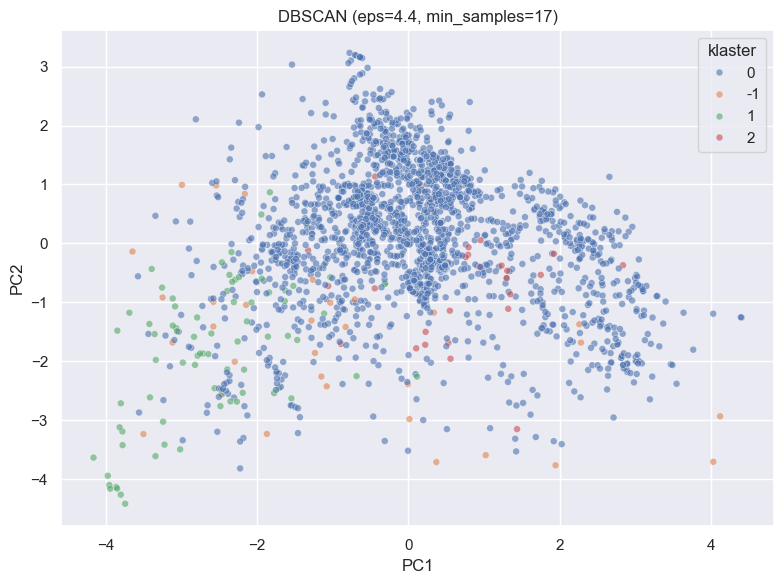

In [39]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['klaster'] = labels_db.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='klaster', alpha=0.6, s=25)
plt.title(f'DBSCAN (eps={my_eps}, min_samples={min_pts})')
plt.tight_layout()
plt.show()

## Analiza i interpretacja wyników DBSCAN

### 1. Liczba i wielkość utworzonych grup

Liczba i wielkość klastrów DBSCAN:
Szum (-1)      32
Klaster 0    1951
Klaster 1      76
Klaster 2      28

Łącznie punktów szumu: 32 (1.5% danych)


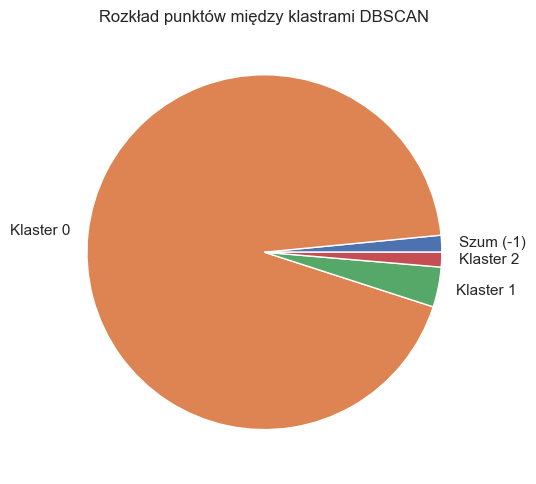

In [40]:
df_result = df_features.copy()
df_result['cluster_dbscan'] = labels_db
df_result['NObeyesdad'] = y_true.values

# Liczba i wielkość klastrów
cluster_counts = pd.Series(labels_db).value_counts().sort_index()
cluster_counts.index = [f'Klaster {i}' if i >= 0 else 'Szum (-1)' for i in cluster_counts.index]
print('Liczba i wielkość klastrów DBSCAN:')
print(cluster_counts.to_string())
print(f'\nŁącznie punktów szumu: {(labels_db == -1).sum()} ({(labels_db == -1).mean()*100:.1f}% danych)')

# Wykres kołowy
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(cluster_counts.values, labels=cluster_counts.index)
ax.set_title('Rozkład punktów między klastrami DBSCAN')
plt.tight_layout()
plt.show()

### 2. Porównanie średnich wartości zmiennych w klastrach

In [41]:
df_no_noise = df_result[df_result['cluster_dbscan'] != -1].copy()
cluster_means = df_no_noise.groupby('cluster_dbscan')[features].mean().T
cluster_means.columns = [f'Klaster {c}' for c in cluster_means.columns]
print('Średnie wartości zmiennych w klastrach:')
print(cluster_means.round(3).to_string())


Średnie wartości zmiennych w klastrach:
                                Klaster 0  Klaster 1  Klaster 2
Gender                              0.512      0.184      0.821
Age                                24.426     19.704     27.277
family_history_with_overweight      0.842      0.408      0.857
FAVC                                0.899      0.658      0.929
FCVC                                2.412      2.607      2.419
NCP                                 2.704      2.585      2.857
CAEC                                1.130      1.329      1.179
SMOKE                               0.000      0.000      1.000
CH2O                                2.008      1.933      1.516
SCC                                 0.000      1.000      0.000
FAF                                 0.999      1.194      0.905
TUE                                 0.662      0.608      0.792
CALC                                0.723      0.671      1.071
MTRANS                              2.348      2.737      2.500


### 3. Analiza obserwacji odstających (klaster -1)

In [42]:
# Analiza punktow szumu
df_noise = df_result[df_result['cluster_dbscan'] == -1][features + ['NObeyesdad']]
df_core  = df_result[df_result['cluster_dbscan'] != -1][features + ['NObeyesdad']]

print(f'Liczba obserwacji odstających (szum): {len(df_noise)}')
print(f'Odsetek szumu: {len(df_noise)/len(df_result)*100:.1f}%')
print('\nRozkład klas otyłości wśród obserwacji odstających:')
print(df_noise['NObeyesdad'].value_counts().to_string())

# Porownanie srednich: szum vs klastry
comp = pd.DataFrame({
    'Klastry (core)': df_core[features].mean(),
    'Szum (-1)':      df_noise[features].mean()
}).round(3)
print('\nPorównanie średnich cech: klastry vs szum:')
print(comp.to_string())

Liczba obserwacji odstających (szum): 32
Odsetek szumu: 1.5%

Rozkład klas otyłości wśród obserwacji odstających:
NObeyesdad
Normal_Weight          14
Overweight_Level_I      9
Obesity_Type_I          4
Insufficient_Weight     2
Overweight_Level_II     2
Obesity_Type_II         1

Porównanie średnich cech: klastry vs szum:
                                Klastry (core)  Szum (-1)
Gender                                   0.504      0.500
Age                                     24.290     28.375
family_history_with_overweight           0.826      0.781
FAVC                                     0.891      0.438
FCVC                                     2.419      2.562
NCP                                      2.701      2.688
CAEC                                     1.138      1.656
SMOKE                                    0.014      0.500
CH2O                                     1.998      2.406
SCC                                      0.037      0.625
FAF                                  

### 4. Porównanie klastrów z danymi o otyłości

In [43]:
crosstab = pd.crosstab(
    df_result['cluster_dbscan'],
    df_result['NObeyesdad'],
    margins=True
)
crosstab.index = [
    'Szum (-1)' if i == -1 else ('Lacznie' if i == 'All' else f'Klaster {i}')
    for i in crosstab.index
]
print('Tabela krzyzowa: klaster DBSCAN x poziom otylosci:')
crosstab

Tabela krzyzowa: klaster DBSCAN x poziom otylosci:


NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II,All
Szum (-1),2,14,4,1,0,9,2,32
Klaster 0,244,241,343,282,323,237,281,1951
Klaster 1,21,21,1,0,0,29,4,76
Klaster 2,0,6,3,14,1,1,3,28
Lacznie,267,282,351,297,324,276,290,2087


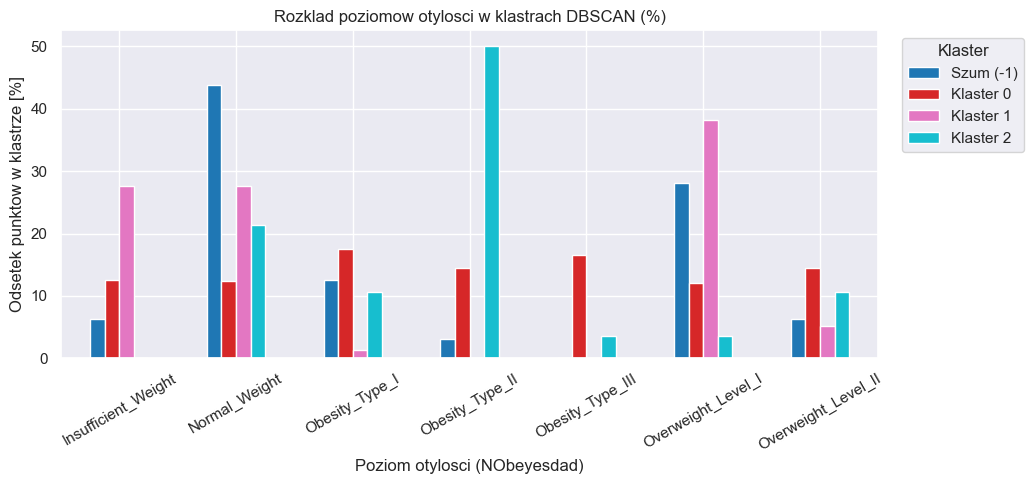

In [44]:
# Procenty w wierszu
crosstab_pct = pd.crosstab(
    df_result['cluster_dbscan'],
    df_result['NObeyesdad'],
    normalize='index'
) * 100
crosstab_pct.index = [f'Klaster {i}' if i != -1 else 'Szum (-1)' for i in crosstab_pct.index]

fig, ax = plt.subplots(figsize=(max(10, len(crosstab_pct.columns)*1.5), 5))
crosstab_pct.T.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Rozklad poziomow otylosci w klastrach DBSCAN (%)')
ax.set_xlabel('Poziom otylosci (NObeyesdad)')
ax.set_ylabel('Odsetek punktow w klastrze [%]')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Klaster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Podsumowanie i wnioski


### Dobor parametrow DBSCAN

- **`min_samples`** = 1 + liczba cech < `minPts` < 2 x liczba cech
- **`eps`** wyznaczony z wykresu k-distance (k = `min_samples`)

### Porownanie klastrow z danymi o otylosci

Rozkład poziomów otyóości w klastrach DBSCAN  pokazuje, w jakim stopniu klastry DBSCAN pokrywaja sie z etykietami `NObeyesdad`. Klastry nie odpowiadają ani troche poziomom otyłości, dlatego ciężko napisać charakterystyke grup

### Wnioski

**Metodyka** - wypadałoby znaleźć inny sposób wyboru `eps` oraz `minPts`

In [47]:
summary = pd.DataFrame({
    'algorytm': ['DBSCAN'],
    'liczba_klastrow': [n_clusters_db],
    'punkty_szumu': [int((labels_db == -1).sum())],
})
print(summary.to_string(index=False))

algorytm  liczba_klastrow  punkty_szumu
  DBSCAN                3            32
